# LOGISTIC REGRESSION

### 1. Data Exploration:

##### a. Load the dataset and perform exploratory data analysis (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

In [2]:
df=pd.read_csv(r"C:\Users\tilna\OneDrive\Desktop\excelr\DS-Assignment\Diabetics prjct\diabetes.csv")

In [3]:
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
## duplicates
df.duplicated().sum()

np.int64(0)

#### b. Examine the features, their types, and summary statistics.


In [7]:
## features and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
## summaary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions andrelationships between features.

<Axes: >

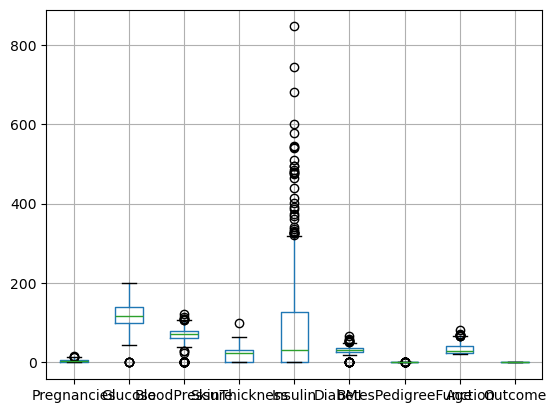

In [9]:
## outlier checking using boxplot
df.boxplot()

In [10]:
## outlier capping
def outlier_capping(df,columns):
    Q1=df[columns].quantile(0.25)
    Q3=df[columns].quantile(0.75)
    IQR=Q3-Q1
    lowwer_ext=Q1-1.5*IQR
    upper_ext=Q3+1.5*IQR
    df[columns]=df[columns].apply(lambda x: lowwer_ext if x<lowwer_ext else upper_ext if x>upper_ext else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

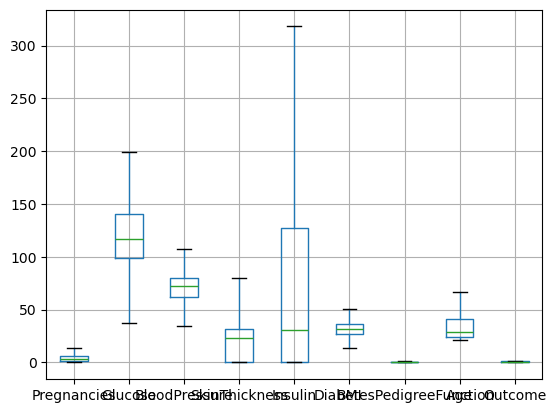

In [11]:
df.boxplot()
plt.show()

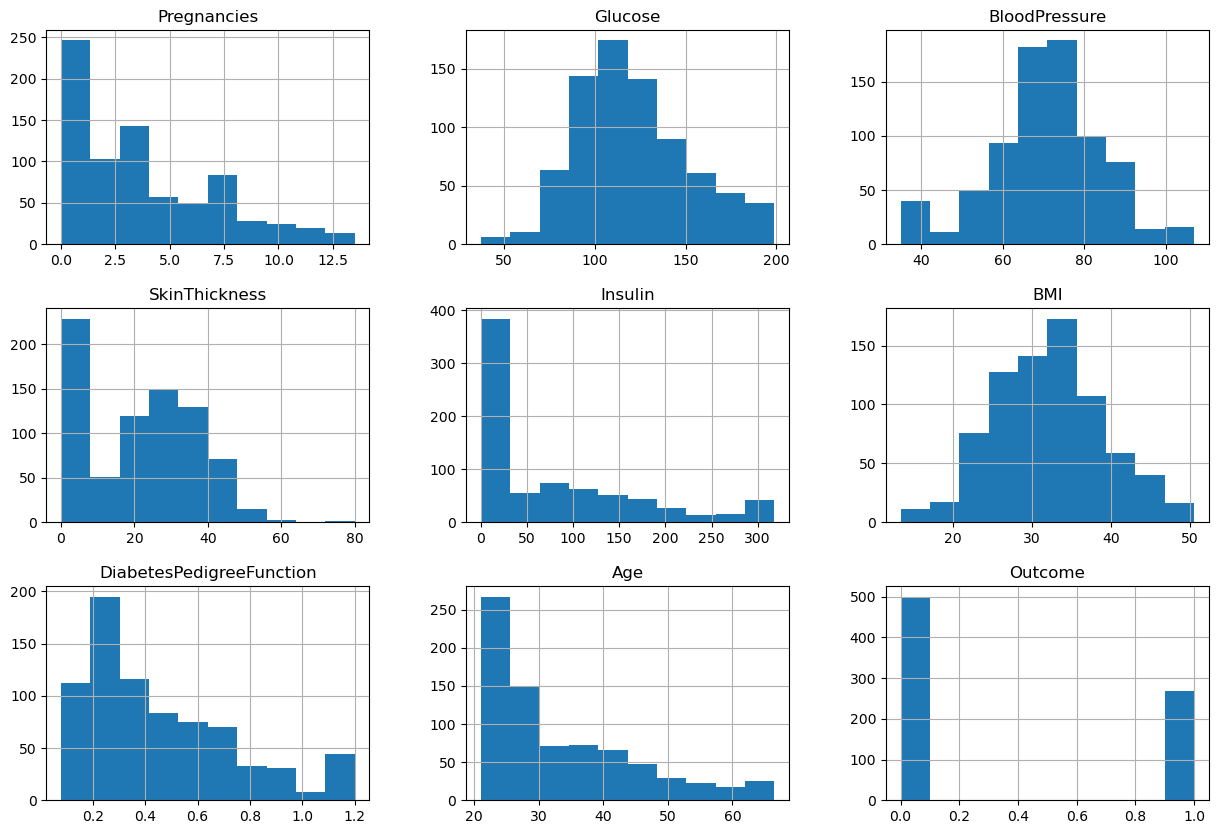

In [12]:
df.hist(figsize=(15,10))
plt.show()

##### Analyze any patterns or correlations observed in the data.

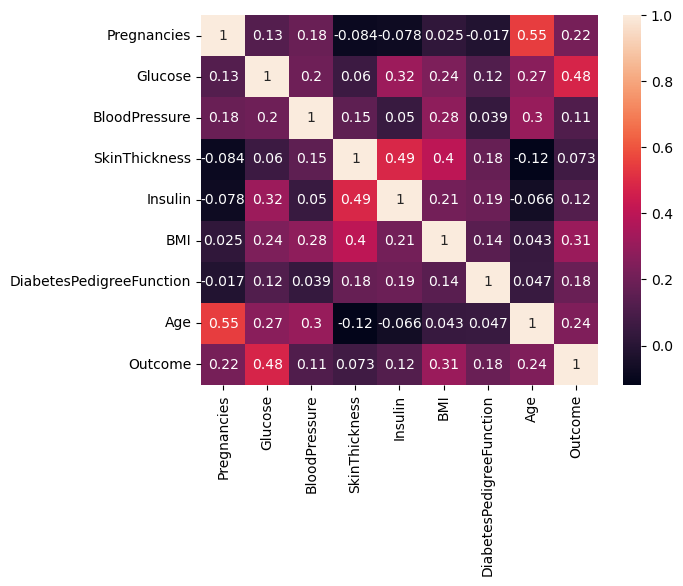

In [13]:
## correlation
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [14]:
##droping column skinthickness as it has correlation with insulin
df.drop(columns=['SkinThickness'],inplace=True)

In [15]:
target=df[['Outcome']]
features=df.drop(columns=['Outcome'])

In [16]:
f_class=f_classif(features,target)
pd.Series(f_class[0],index=features.columns).sort_values(ascending=False)

Glucose                     228.278996
BMI                          81.287147
Age                          47.944757
Pregnancies                  39.106100
DiabetesPedigreeFunction     27.135876
Insulin                      12.103615
BloodPressure                 9.961146
dtype: float64

In [17]:
## droping BloodPressure bcz of less correlation with target
features.drop(columns=['BloodPressure'],inplace=True)

### 2. Data Preprocessing:

##### a. Handle missing values (e.g., imputation).

##### b. Encode categorical variables.

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,168.0,43.1,1.200,33.0,1


In [19]:
## scaling

In [20]:
std_sca=StandardScaler()
features = pd.DataFrame(std_sca.fit_transform(features), columns=features.columns)
features

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.861926,-0.787602,0.209359,0.588927,1.445691
1,-0.848970,-1.159433,-0.787602,-0.784254,-0.378101,-0.189304
2,1.245598,1.984903,-0.787602,-1.252672,0.746595,-0.103252
3,-0.848970,-1.031093,0.217583,-0.571337,-1.022787,-1.049828
4,-1.148194,0.508990,1.008900,1.557835,2.596563,-0.017199
...,...,...,...,...,...,...
763,1.844045,-0.646072,1.137221,0.109998,-1.008772,2.564372
764,-0.549746,0.027714,-0.787602,0.663583,-0.416642,-0.533513
765,0.347926,-0.004371,0.410066,-0.841032,-0.749497,-0.275356
766,-0.848970,0.156054,-0.787602,-0.287447,-0.385109,1.187534


### 3. Model Building:

##### a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
##### b. Train the model using the training data.

In [21]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100,stratify=None)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 6)
(154, 6)
(614, 1)
(154, 1)


In [22]:
std_sca=StandardScaler()
x_train=std_sca.fit_transform(x_train)
x_test=std_sca.transform(x_test)

In [23]:
str_shuffle=StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=50)

In [29]:
## intercept
log_model=LogisticRegression()
log_model.fit(x_train,y_train)

LogisticRegression()

In [30]:
log_model.intercept_

array([-0.89863857])

### 4. Model Evaluation:

##### a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

In [34]:
cross=cross_validate(LogisticRegression(),features,target,scoring=['accuracy'],cv=str_shuffle,return_train_score=True)

In [35]:
train_acc=cross['train_accuracy'].mean().round(2)
test_acc=cross['test_accuracy'].mean().round(2)
print(f'Train Accuracy:{train_acc}\nTest Accuracy:{test_acc}')

Train Accuracy:0.78
Test Accuracy:0.78


In [36]:
## performance metrics
from sklearn.metrics import classification_report,roc_auc_score,roc_curve

In [33]:
print(classification_report(y_test,y_pred1))

NameError: name 'y_pred1' is not defined

In [ ]:
pred_prob=log_reg.predict_proba(x_test)
sigmoid=pred_prob[:,1]

In [ ]:
auc_score=roc_auc_score(y_test,sigmoid)
auc_score

##### Visualize the ROC curve.

In [ ]:
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,color='red',lw=2,label=f'Auc_score:{auc_score:2f}')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('False Positive Rate',color='red',size=10)
plt.ylabel('True Positive Rate',color='red',size=10)
plt.title('ROC Curve',color='red',size=10)
plt.legend()
plt.grid()
plt.show()

### 5. Interpretation:

##### a. Interpret the coefficients of the logistic regression model.

In [ ]:
#coeff
coefficient=pd.DataFrame({'features':features.columns,'coefficient':log_reg.coef_[0]}).sort_values(by='coefficient',ascending=False,ignore_index=True)
coefficient['Effect'] = np.where(coefficient['coefficient'] > 0, 
                                  'Increases chance of diabetes', 
                                  'Decreases chance of diabetes')
coefficient

##### b. Discuss the significance of features in predicting the target variable (survival probability in thiscase).

### 6. Deployment with Streamlit:

In [ ]:
import pickle

# Save the trained model
pickle.dump(log_reg, open('log_reg_model.pkl', 'wb'))
pickle.dump(std_sca, open('scaler.pkl', 'wb'))
print("Model saved successfully!")


### Interview Questions:

##### 1. What is the difference between precision and recall?

##### 2. What is cross-validation, and why is it important in binary classification?